# This file contains Processes Exercises of Lectures 1

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
from cartopy.io import shapereader
from rich import print
import matplotlib.pyplot as plt
import xarray as xr

# Loading the Moselle Data

In [6]:
# Name of shapefile/region
own_region = "Moselle"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}Forcing"

#Shape area
shape_area_moselle = 28101 * 1000000 #m2

# Load ERA5 data
ERA5_forcing_moselle = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

FileNotFoundError: Forcing file /home/group10/teaching-materials/book/exercise_journal_ann_laura/Exercises/Forcing/MoselleForcing/ewatercycle_forcing.yaml not found. Perhaps you want to use LumpedMakkinkForcing(...)?

In [7]:
# Period of interest
experiment_start_time = "2003-01-01T00:00:00Z"
experiment_end_time = "2012-12-31T00:00:00Z"

In [6]:
#precip and evap
C_evap = ERA5_forcing_Moselle.to_xarray()["evap"]
C_prec = ERA5_forcing_Moselle.to_xarray()["pr"]
C_evap = C_evap * 86400 # mm/day
C_prec = C_prec * 86400 # mm/day



In [7]:
# Discharge data 
C_obs = pd.read_excel('filename', index_col=[0])
C_obs = C_obs / 1000 # m3/s
C_obs = C_obs * 86400 / shape_area * 1000 # mm/day
C_obs.loc[C_obs['Q'] > 4000, 'Q'] = np.nan
C_obs_1 = C_obs.loc['2003-01-01':'2012-12-31']
C_obs_data = C_obs_1['Q'].to_xarray().rename({'Day': 'time'})

NameError: name 'T_evap' is not defined

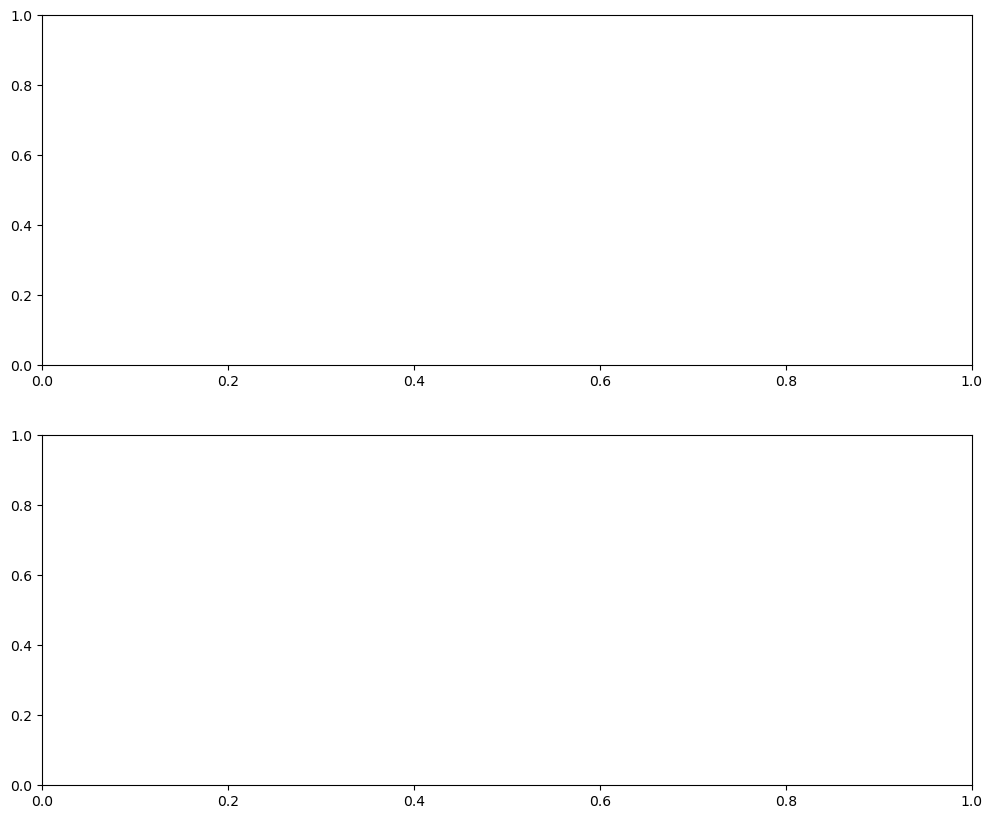

In [8]:
# Test
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12,10))

T_evap.plot(ax=axs[0], label='Potential evaporation')
T_prec.plot(ax=axs[0], label='Precipitation')
axs[0].set_title(f'Forcing data for the region: Moselle')
axs[0].set_ylabel('mm/d')
axs[0].legend()



# Processes 1.1: Catchment Functioning, Macroscale Laws & Change

In [10]:
C_evap["time"] = C_evap["time"].dt.date
C_prec["time"] = C_prec["time"].dt.date
T_evap["time"] = T_evap["time"].dt.date
T_prec["time"] = T_prec["time"].dt.date

In [9]:
C_evap.name = "EP mm/d" 
C_prec.name = "P mm/d"
C_obs_data.name = "Q mm/d"

df = xr.merge([C_prec, C_evap, C_obs_data]).to_dataframe()
Moselle = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Moselle.index = pd.to_datetime(Moselle.index)
Moselle

NameError: name 'C_evap' is not defined

In [12]:
T_evap.name = "EP mm/d" 
T_prec.name = "P mm/d" 
T_obs_data.name = "Q mm/d"

df = xr.merge([T_prec, T_evap, T_obs_data]).to_dataframe()
Moselle = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Moselle.index = pd.to_datetime(Moselle.index)
Moselle

,P mm/d,EP mm/d,Q mm/d
time,,,
2013-01-18,2.727902,3.381890,4.831902
2013-01-19,11.383754,1.061304,5.354410
2013-01-20,1.549613,2.731830,9.533436
2013-01-21,0.735289,3.090874,4.914676
2013-01-22,30.597606,0.973964,4.122637
...,...,...,...
2019-09-23,5.792398,4.396816,1.872750
2019-09-24,1.107592,4.824052,1.844297
2019-09-25,3.119946,4.770987,1.787390


In [13]:
# Budyko line
ep_p = np.arange(0.01, 5.25, 0.25)
budyko = (ep_p * np.tanh(1 / ep_p) * (1 - np.exp(-ep_p))) ** (1/2)

# EP / P
EP_P = Moselle['EP mm/d'].mean() / Moselle['P mm/d'].mean()

# Budyko
EA_P_b = (EP_P * np.tanh(1 / EP_P) * (1 - np.exp(-EP_P))) ** (1/2)

# Water balance
EA_P_w = 1 - Moselle['Q mm/d'].mean() / Moselle['P mm/d'].mean()

In [15]:
# Limits
EP_energy_limit = np.array([0,1])
EA_energy_limit = np.array([0,1])
EP_water_limit = np.arange(1,6)
EA_water_limit = np.ones(5)

In [1]:
# Plot
plt.plot(EP_water_limit, EA_water_limit, label='Water limit')
plt.plot(EP_energy_limit, EA_energy_limit, label='Energy limit')
plt.plot(ep_p, budyko, label='Budyko Curve')
plt.scatter(EP_P, EA_P_b, label='Budyko Moselle', color='purple')
plt.scatter(EP_P, EA_P_w, label='Water Balance Moselle', color='red')
plt.title('Budyko Framework')
plt.legend()
plt.xlabel('Ep / P [-]')
plt.ylabel('Ea / P [-]')

NameError: name 'plt' is not defined

In [2]:
# Losses 
L1 = (EA_P_w - EA_P_b) * Moselle['P mm/d'].mean()

L1, L2

NameError: name 'EA_P_w' is not defined

In [18]:
# Check Long-term Storage = 0
S1 = Moselle['P mm/d'].mean() - Moselle['Q mm/d'].mean() - EA_P_b * Moselle['P mm/d'].mean() - L1

S1

(4.440892098500626e-16, 2.220446049250313e-16)

# Processes 1.2: Flow Duration Curve

In [11]:
# Flow duration curve based on ...years of discharge data 
filename = "Flow duration curve data.xlsx"
df_fdc = pd.read_excel(filename, index_col=0, parse_dates=True, skiprows = 1)
df_fdc.columns = ["Flow1", "Flow2"]
df_fdc.head()

df_fdc.plot()

flow1 = df_fdc["Flow1"]
flow2 = df_fdc["Flow2"]

sorted_1 = flow1.sort_values(ascending=False)
sorted_2 = flow2.sort_values(ascending=False)

n_data = len(sorted_1)

rank = np.arange(1, n_data + 1)
exceedance_probability = rank / (n_data + 1)

plt.figure(figsize=(8,6))

plt.plot(exceedance_probability, sorted_1, label="Flow 1")
plt.plot(exceedance_probability, sorted_2, label="Flow 2")
plt.yscale("log")

plt.xlabel("Exceedance Probability")
plt.ylabel("Flow")
plt.legend()
plt.grid()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Flow duration curve data.xlsx'

# Processes 1.3: Autocorrelaton

In [12]:
# Auto correlation based on ... years of discharge data Moselle
filename = "Autocorrelation function data.xlsx"
df_acf = pd.read_excel(filename, index_col=0, parse_dates=True, skiprows = 1)
df_acf.head()
df_acf.columns = ["Flow1", "Flow2"]

lags = np.arange(30)
auto1 = []
auto2 = []
for i in range(len(lags)):
    auto1.append(df_acf["Flow1"].autocorr(lag = i))
    auto2.append(df_acf["Flow2"].autocorr(lag = i))


plt.plot(lags, auto1, label="Flow 1")
plt.plot(lags, auto2, label="Flow 2")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Discharge Autocorrelogram")
plt.legend()
plt.show()
plt.plot(df_acf["Flow1"], label="Flow 1")
plt.plot(df_acf["Flow2"], label="Flow 2")
plt.xlabel("Time")
plt.ylabel("Discharge")
plt.title("Flow Time Series")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Autocorrelation function data.xlsx'